# 2/15   Урок 2. Доверительные интервалы


## Доверительный интервал для среднего нормальной популяции


Рассмотрим, как именно строится доверительный интервал для среднего нормального распределения. Начнём с простейшей ситуации — когда известна дисперсия $\sigma^2$.

In [15]:
import numpy as np
from scipy.stats import norm

np.random.seed(1)
n = 25
mu_true = 5.0
sigma = 2.0  # известно
data = np.random.normal(loc=mu_true, scale=sigma, size=n)
xbar = data.mean()
alpha = 0.05
z = norm.ppf(1 - alpha/2)
ci_lower = xbar - z * sigma / np.sqrt(n)
ci_upper = xbar + z * sigma / np.sqrt(n)
print(f"x̄ = {xbar:.3f}, {100*(1-alpha):.0f}% CI = [{ci_lower:.3f}, {ci_upper:.3f}]")

x̄ = 4.975, 95% CI = [4.191, 5.759]


Когда генеральная дисперсия $\sigma^2$ неизвестна — что в реальности происходит почти всегда, её приходится оценивать по выборке. В этом случае распределение статистики уже нельзя считать строго нормальным, оно будет подчиняться распределению Стьюдента — и доверительный интервал будет строиться на его основе.

In [2]:
from scipy.stats import t

s = data.std(ddof=1)
t_q = t.ppf(1 - alpha/2, df=n-1)
ci_t = (xbar - t_q * s / np.sqrt(n), xbar + t_q * s / np.sqrt(n))
print(f"{100*(1-alpha):.0f}% t-CI = [{ci_t[0]:.3f}, {ci_t[1]:.3f}]")

95% t-CI = [4.068, 5.881]


Обратите внимание, если точно известно $\sigma$, то следует выбирать первый вариант. В реальности это редко случается, поэтому на практике чаще приходится использовать t. При больших $n$ (обычно $n\gtrsim 30$) t и z почти совпадают из-за сходимости t к нормали.

## Интервалы для дисперсии $\chi^2$

Помимо оценки среднего, часто важно понять, каков разброс в самих данных — то есть оценить дисперсию генеральной совокупности. Как и для среднего, вместо одной точечной оценки $s^2$ можно построить доверительный интервал для истинной дисперсии $\sigma^2$.

В случае нормальной выборки существует точное соотношение между выборочной и генеральной дисперсией, которое выражается через распределение $\chi^2$ (хи-квадрат). Это позволяет построить интервал, в котором с вероятностью $(1 - \alpha)$ лежит истинная дисперсия.

In [3]:
from scipy.stats import chi2

chi2_low = chi2.ppf(alpha/2, df=n-1)
chi2_high = chi2.ppf(1-alpha/2, df=n-1)
ci_var = ((n-1)*s*s / chi2_high, (n-1)*s*s / chi2_low)
ci_sigma = (np.sqrt(ci_var[0]), np.sqrt(ci_var[1]))
print(f"CI for sigma^2: [{ci_var[0]:.3f}, {ci_var[1]:.3f}]")
print(f"CI for sigma: [{ci_sigma[0]:.3f}, {ci_sigma[1]:.3f}]")

CI for sigma^2: [2.941, 9.335]
CI for sigma: [1.715, 3.055]


## Интервалы для доли


Во многих задачах нас интересует не среднее или дисперсия, а доля успехов — т.е. вероятность наступления события. Например, доля покупателей, совершивших покупку, или доля бракованных деталей в партии.

Пусть $X\sim\operatorname{Bin}(n,p)$, наблюдаем число успехов $k$. Популярный (но ненадёжный при малых $n$ или $p$ близких к 0/1) — Wald-интервал рассчитывается как:

$\hat p = \frac{k}{n}, \quad \hat p \pm z_{1-\alpha/2}\sqrt{\frac{\hat p(1-\hat p)}{n}}$

Лучше использовать Agresti–Coull интервал — он практически всегда надёжен и рассчитывается как:

$\tilde n = n + z^2, \quad \tilde p = \frac{k + z^2/2}{\tilde n}$

Реализуем интервалы для доли на Python — встроенных методов в scipy на этот раз нет, поэтому сделаем расчёт вручную по формулам:

In [4]:
import numpy as np
from scipy.stats import norm

k = 45       # число успехов
n = 100      # число испытаний
alpha = 0.05 # уровень значимости

# Квантиль нормального распределения
z = norm.ppf(1 - alpha/2)

# Wald-интервал
p_hat = k / n
wald_lower = p_hat - z * np.sqrt(p_hat * (1 - p_hat) / n)
wald_upper = p_hat + z * np.sqrt(p_hat * (1 - p_hat) / n)

# Agresti-Coull-интервал
n_tilde = n + z**2
p_tilde = (k + z**2 / 2) / n_tilde
agresti_lower = p_tilde - z * np.sqrt(p_tilde * (1 - p_tilde) / n_tilde)
agresti_upper = p_tilde + z * np.sqrt(p_tilde * (1 - p_tilde) / n_tilde)

## Бутстрэп-интервалы


Иногда распределение статистики (например, среднего или медианы) слишком сложно, чтобы вывести для него формулу доверительного интервала. В таких случаях помогает бутстрэп — универсальный вычислительный метод, который оценивает неопределённость с помощью повторных случайных выборок из имеющихся данных.

Идея бутстрэпа проста: используем исходную выборку как приближение всей совокупности и многократно «переигрываем» эксперимент — случайным образом выбираем из неё наблюдения с возвращением. Сформулируем алгоритм пошагово:

Многократно (обычно 1000–10000 раз) и случайно выбираем из исходной выборки те же данные с возвращением — т.е. возможная ситуация, что один и тот же элемент попадёт в выборку несколько раз, а другой — ни разу. Каждая такая новая выборка называется бутстрэп-выборкой и моделирует, как могла бы выглядеть наша выборка при повторении эксперимента.
Для каждой выборки вычисляем интересующую статистику — например, среднее, медиану или коэффициент регрессии.
В результате получаем эмпирическое распределение бутстрэп-статистики, которое отражает разброс оценок, возникающий из-за случайности выборки.
Чтобы построить бутстрэп-доверительный интервал, берём квантили этого распределения: нижний — на уровне $\alpha/2$, верхний — на уровне $1 - \alpha/2$. Эти значения образуют так называемый percentile bootstrap CI — доверительный интервал, построенный на основе квантилей эмпирического распределения.

In [5]:
def bootstrap_ci(data, statfunc=np.mean, B=2000, alpha=0.05):
    n = len(data)
    boot_stats = np.empty(B)
    for i in range(B):
        sample = np.random.choice(data, size=n, replace=True)
        boot_stats[i] = statfunc(sample)
    lo = np.quantile(boot_stats, alpha/2)
    hi = np.quantile(boot_stats, 1-alpha/2)
    return lo, hi

ci_boot = bootstrap_ci(data, statfunc=np.mean, B=5000)
print("Bootstrap percentile CI:", ci_boot)

Bootstrap percentile CI: (4.131651617565472, 5.824553738938231)


Таким образом, бутстрэп позволяет оценить доверительные интервалы без строгих предположений о виде распределения, что делает его особенно полезным в реальных задачах анализа данных.

## Задачи и упражнения



**Упражнение 1**

Сгенерирована выборка размера $n=25$ из $N(5, 2^2)$ (seed = 1). Если использовать z-доверительный интервал для $\mu$ при известной $\sigma$ и уровне доверия 95%, то какая из следующих границ верна?
(3.22, 6.78)
(4.22, 5.78)
(4.00, 6.00)
(4.50, 5.50)

In [20]:
import numpy as np
from scipy.stats import norm

np.random.seed(1)
n = 25
mu_true = 5.0
sigma = 2.0  # известно
data = np.random.normal(loc=mu_true, scale=sigma, size=n)
xbar = data.mean()
alpha = 0.05
z = norm.ppf(1 - alpha/2)
ci_lower = xbar - z * sigma / np.sqrt(n)
ci_upper = xbar + z * sigma / np.sqrt(n)
print(f"x̄ = {xbar:.3f}, {100*(1-alpha):.0f}% CI = [{ci_lower:.3f}, {ci_upper:.3f}]")

x̄ = 4.975, 95% CI = [4.191, 5.759]


**Упражнение 2.1**

Используя ту же выборку $(n = 25,\; \bar X \approx 5.05,\; s^2 \approx 3.78)$, постройте 95% доверительный интервал для дисперсии $\sigma^2$ и стандартного отклонения $\sigma$ с помощью $\chi^2$-формулы. В поле ответа укажите нижнюю границу, округлив до 2 знаков, в качестве разделителя используйте точку.
Подсказка:

$CI_{\sigma^2} = \left[\frac{(n-1)s^2}{\chi^2_{0.975}}, \frac{(n-1)s^2}{\chi^2_{0.025}}\right], 
\quad
CI_\sigma = \sqrt{CI_{\sigma^2}}$

In [26]:
from scipy.stats import chi2
s = data.mean()
# s = 3.78
chi2_low = chi2.ppf(alpha/2, df=n-1)
chi2_high = chi2.ppf(1-alpha/2, df=n-1)
ci_var = ((n-1)*s*s / chi2_high, (n-1)*s*s / chi2_low)
ci_sigma = (np.sqrt(ci_var[0]), np.sqrt(ci_var[1]))
print(f"CI for sigma^2: [{ci_var[0]:.3f}, {ci_var[1]:.3f}]")
print(f"CI for sigma: [{ci_sigma[0]:.3f}, {ci_sigma[1]:.3f}]")

CI for sigma^2: [15.087, 47.891]
CI for sigma: [3.884, 6.920]


In [18]:
alpha

0.05

In [27]:
n, s, s**2, xbar,

(25, 4.974540224973695, 24.74605044988134, 4.974540224973695)

данные в выборке (сигма) не сходятся с данными на платформе, считаем, что в коде правильные

**Упражнение 4.1**

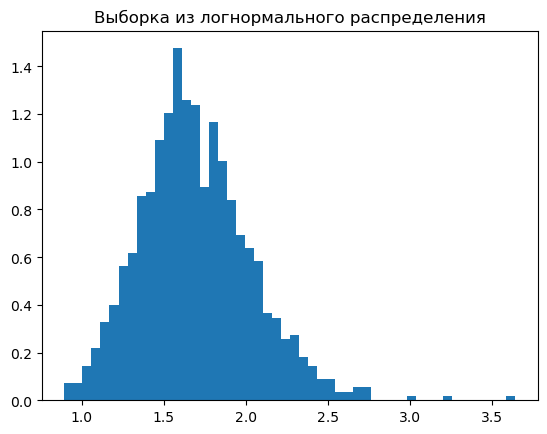

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры для исходного нормального распределения
mu = 0.5  # Среднее логарифмов
sigma = 0.2 # Стандартное отклонение логарифмов
size = 1000 # Количество точек для генерации

# Генерация логнормальной выборки
lognormal_sample = np.random.lognormal(mean=mu, sigma=sigma, size=size)

# Визуализация (опционально)
plt.hist(lognormal_sample, bins=50, density=True)
plt.title('Выборка из логнормального распределения')
plt.show()


In [32]:
import numpy as np
import pandas as pd
from scipy import stats

# Устанавливаем seed для воспроизводимости
np.random.seed(0)

# Параметры логнормального распределения
meanlog = 0.5
sdlog = 0.8
n = 50

# Генерация выборки из логнормального распределения
sample = np.random.lognormal(mean=meanlog, sigma=sdlog, size=n)

print(f"Размер выборки: n = {n}")
print(f"Выборочное среднее: {np.mean(sample):.4f}")
print(f"Выборочное стандартное отклонение: {np.std(sample, ddof=1):.4f}")

# a) Асимптотический 95% доверительный интервал (по ЦПТ)
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)
se = sample_std / np.sqrt(n)  # стандартная ошибка среднего
z_critical = stats.norm.ppf(0.975)  # 1.96 для 95% ДИ

ci_lower_clt = sample_mean - z_critical * se
ci_upper_clt = sample_mean + z_critical * se

print(f"\nа) Асимптотический 95% ДИ по ЦПТ:")
print(f"   Нижняя граница: {ci_lower_clt:.4f}")
print(f"   Верхняя граница: {ci_upper_clt:.4f}")

# b) Bootstrap percentile 95% доверительный интервал
B = 5000
bootstrap_means = np.zeros(B)

for i in range(B):
    # Генерируем bootstrap-выборку с повторениями
    bootstrap_sample = np.random.choice(sample, size=n, replace=True)
    bootstrap_means[i] = np.mean(bootstrap_sample)

# Находим 2.5% и 97.5% процентили
ci_lower_boot = np.percentile(bootstrap_means, 2.5)
ci_upper_boot = np.percentile(bootstrap_means, 97.5)

print(f"\nb) Bootstrap percentile 95% ДИ (B = {B}):")
print(f"   Нижняя граница: {ci_lower_boot:.4f}")
print(f"   Верхняя граница: {ci_upper_boot:.4f}")

# Ответ: нижняя граница bootstrap CI, округленная до 2 знаков после запятой
answer = round(ci_lower_boot, 2)
print(f"\nНижняя граница bootstrap CI (ответ): {answer}")

Размер выборки: n = 50
Выборочное среднее: 2.6907
Выборочное стандартное отклонение: 2.4216

а) Асимптотический 95% ДИ по ЦПТ:
   Нижняя граница: 2.0195
   Верхняя граница: 3.3619

b) Bootstrap percentile 95% ДИ (B = 5000):
   Нижняя граница: 2.0766
   Верхняя граница: 3.4000

Нижняя граница bootstrap CI (ответ): 2.08
